<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_4_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to networkx

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

!pip install git+https://github.com/Hsins/mpl-tc-fonts.git

import mpl_tc_fonts
mpl_tc_fonts.load_font('cwtex', 'copy')
mpl_tc_fonts.set_font('Noto Sans CJK TC')

  Cloning https://github.com/Hsins/mpl-tc-fonts.git to /tmp/pip-req-build-khi9dn9h
  Running command git clone --filter=blob:none --quiet https://github.com/Hsins/mpl-tc-fonts.git /tmp/pip-req-build-khi9dn9h
  Resolved https://github.com/Hsins/mpl-tc-fonts.git to commit 0cc159a2dbf1eb199f0bd847eabfee75403346b6
  Preparing metadata (setup.py) ... done
  Created wheel for mpl-tc-fonts: filename=mpl_tc_fonts-1.0.1-py3-none-any.whl size=133579069 sha256=44a7953972809855720f737b288224a6974bdf0a9558535c3036db49e18b1121
  Stored in directory: /tmp/pip-ephem-wheel-cache-8qmb_h70/wheels/a4/81/c6/7c1e397a0414d972bb2b620a097493da607ede8d186f7f690b
Successfully built mpl-tc-fonts


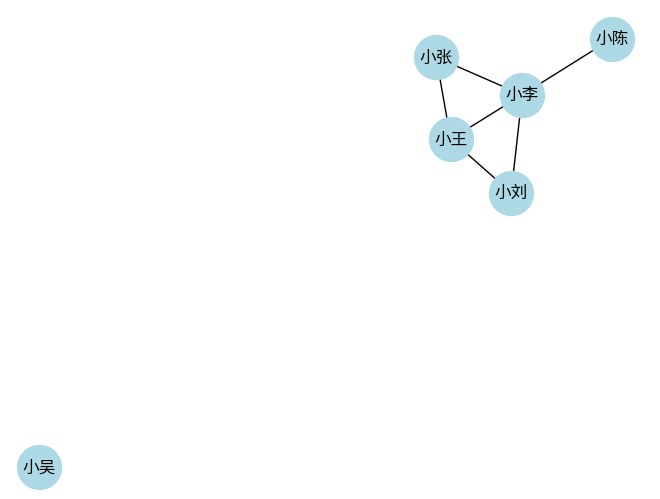

In [18]:
G = nx.Graph()

my_nodes = ["小王", "小李", "小张", "小刘", "小吴", "小陈"]

G.add_nodes_from(my_nodes)

my_edges = [("小王", "小张"), ("小李", "小刘"), ("小王", "小李"), ("小刘", "小王"), ("小张", "小李"), ("小陈", "小李")]

G.add_edges_from(my_edges)

plt.figure()
nx.draw(G,with_labels=True, node_color="lightblue", node_size=1000)
plt.show()

In [19]:
# Calculate and display the degree of each node
print("Node Degrees:")
for node in G.nodes():
    print(f"{node}: {G.degree(node)}")

Node Degrees:
小王: 3
小李: 4
小张: 2
小刘: 2
小吴: 0
小陈: 1


In [20]:
# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)
print("Degree Centrality:")
for node, centrality in degree_centrality.items():
    print(f"{node}: {centrality:.2f}")

Degree Centrality:
小王: 0.60
小李: 0.80
小张: 0.40
小刘: 0.40
小吴: 0.00
小陈: 0.20


In [22]:
# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)
print("Betweenness Centrality:")
for node, centrality in betweenness_centrality.items():
    print(f"{node}: {centrality:.2f}")

Betweenness Centrality:
小王: 0.05
小李: 0.35
小张: 0.00
小刘: 0.00
小吴: 0.00
小陈: 0.00


In [24]:
# Calculate closeness centrality
closeness_centrality = nx.closeness_centrality(G)
print("Closeness Centrality:")
for node, centrality in closeness_centrality.items():
    print(f"{node}: {centrality:.2f}")

Closeness Centrality:
小王: 0.64
小李: 0.80
小张: 0.53
小刘: 0.53
小吴: 0.00
小陈: 0.46


小李


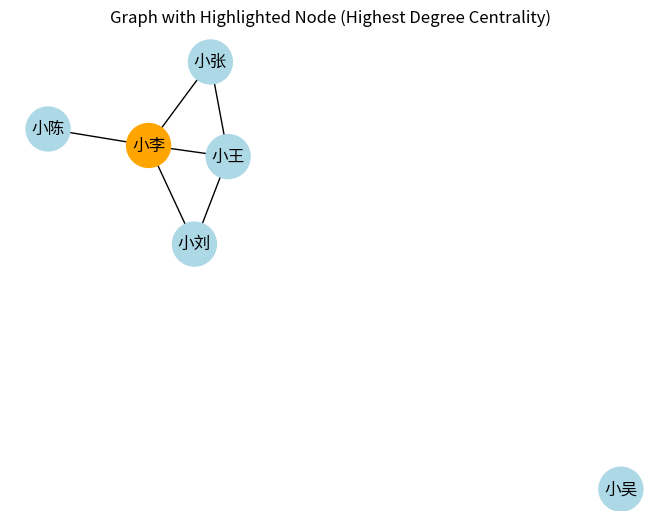

In [29]:
# Find the node with the highest degree centrality
most_important_node = max(degree_centrality, key=degree_centrality.get)

print(most_important_node)

# Draw the graph, highlighting the most important node
plt.figure()
nx.draw(
    G,
    with_labels=True,
    node_color=["lightblue" if node != most_important_node else "orange" for node in G.nodes()],
    node_size=1000
)
plt.title("Graph with Highlighted Node (Highest Degree Centrality)")
plt.show()

# Historical Network Analysis

In [32]:
!wget https://github.com/mcjkurz/qhchina/raw/refs/heads/main/tutorials/data/cbdb-ming-letters-export.csv

--2024-11-12 02:13:17--  https://github.com/mcjkurz/qhchina/raw/refs/heads/main/tutorials/data/cbdb-ming-letters-export.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/cbdb-ming-letters-export.csv [following]
--2024-11-12 02:13:18--  https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/cbdb-ming-letters-export.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7835247 (7.5M) [application/octet-stream]
Saving to: ‘cbdb-ming-letters-export.csv’

cbdb-ming-letters-e 100%[===================>]   7.47M  --.-KB/s    in 0.0

In [36]:
import pandas as pd

# Load the CSV file
file_path = 'cbdb-ming-letters-export.csv'  # Replace with the path to your CSV file
data = pd.read_csv(file_path)

data

<ipython-input-36-8b8a00b460af>:5: DtypeWarning: Columns (10,11,12,14,15,18,19,22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,line,writer,sequence,w_dob,w_dod,person_id,title,assoc_type,assoc_person,a_iy,...,assoc_year,nianhao,year,range,collection,c_source,volume,css_seq,css_id,notes
0,51,羅倫,1,NaN,NaN,34531.0,在告與三閤老,致書Y,se,NaN,...,NaN,NaN,NaN,NaN,一峰先生文集,7204,8,NaN,NaN,NaN
1,52,羅倫,2,NaN,NaN,34531.0,在告與崔冡宰,致書Y,崔恭 (66979),NaN,...,NaN,NaN,NaN,NaN,一峰先生文集,7204,8,NaN,NaN,NaN
2,53,羅倫,3,NaN,NaN,34531.0,與李賔之,致書Y,李東陽 (28691),NaN,...,NaN,NaN,NaN,NaN,一峰先生文集,7204,8,NaN,NaN,NaN
3,54,羅倫,4,NaN,NaN,34531.0,與劉用光,致書Y,劉煊 (199087),NaN,...,NaN,NaN,NaN,NaN,一峰先生文集,7204,8,NaN,NaN,NaN
4,55,羅倫,5,NaN,NaN,34531.0,復胡提學書,答Y書,胡榮 (129075),NaN,...,NaN,NaN,NaN,NaN,一峰先生文集,7204,8,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54526,55196,釋袾宏,136,1535,1615.0,34791.0,答姜居士,答Y書,NaN,NaN,...,NaN,NaN,NaN,NaN,雲棲大師遺稿,66676.0,3.0,NaN,NaN,NaN
54527,55197,釋袾宏,137,1535,1615.0,34791.0,答吳士瑾居士,答Y書,NaN,NaN,...,NaN,NaN,NaN,NaN,雲棲大師遺稿,66676.0,3.0,NaN,NaN,NaN
54528,55198,釋袾宏,138,1535,1615.0,34791.0,答吳廣穎居士,答Y書,NaN,NaN,...,NaN,NaN,NaN,NaN,雲棲大師遺稿,66676.0,3.0,NaN,NaN,NaN
54529,55199,釋袾宏,139,1535,1615.0,34791.0,答董廣曙居士,答Y書,NaN,NaN,...,NaN,NaN,NaN,NaN,雲棲大師遺稿,66676.0,3.0,NaN,NaN,NaN


In [40]:
# Define a reusable condition for filtering
def is_valid(value):
    if value in ['cd', 'se', '']:
      return False
    if pd.isna(value):
      return False
    return True

# Apply the filtering condition once and extract the receiver
data['receiver'] = data['assoc_person'].str.extract(r'^(.*)\s\(\d+\)$')[0]

# Filter out rows where writer or receiver are not valid
filtered_data = data[data['writer'].apply(is_valid) & data['receiver'].apply(is_valid)]

# Select only the writer and receiver columns

result = filtered_data[['writer', 'receiver']]
result

,writer,receiver
1,羅倫,崔恭
2,羅倫,李東陽
3,羅倫,劉煊
4,羅倫,胡榮
5,羅倫,周孟中
...,...,...
54506,釋袾宏,何士晉
54507,釋袾宏,虞淳熙
54509,釋袾宏,王弘誨
54515,釋袾宏,朱鷺


In [44]:
result.iloc[0]["receiver"]

'崔恭'

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 166399 (\N{CJK UNIFIED IDEOGRAPH-289FF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 156921 (\N{CJK UNIFIED IDEOGRAPH-264F9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


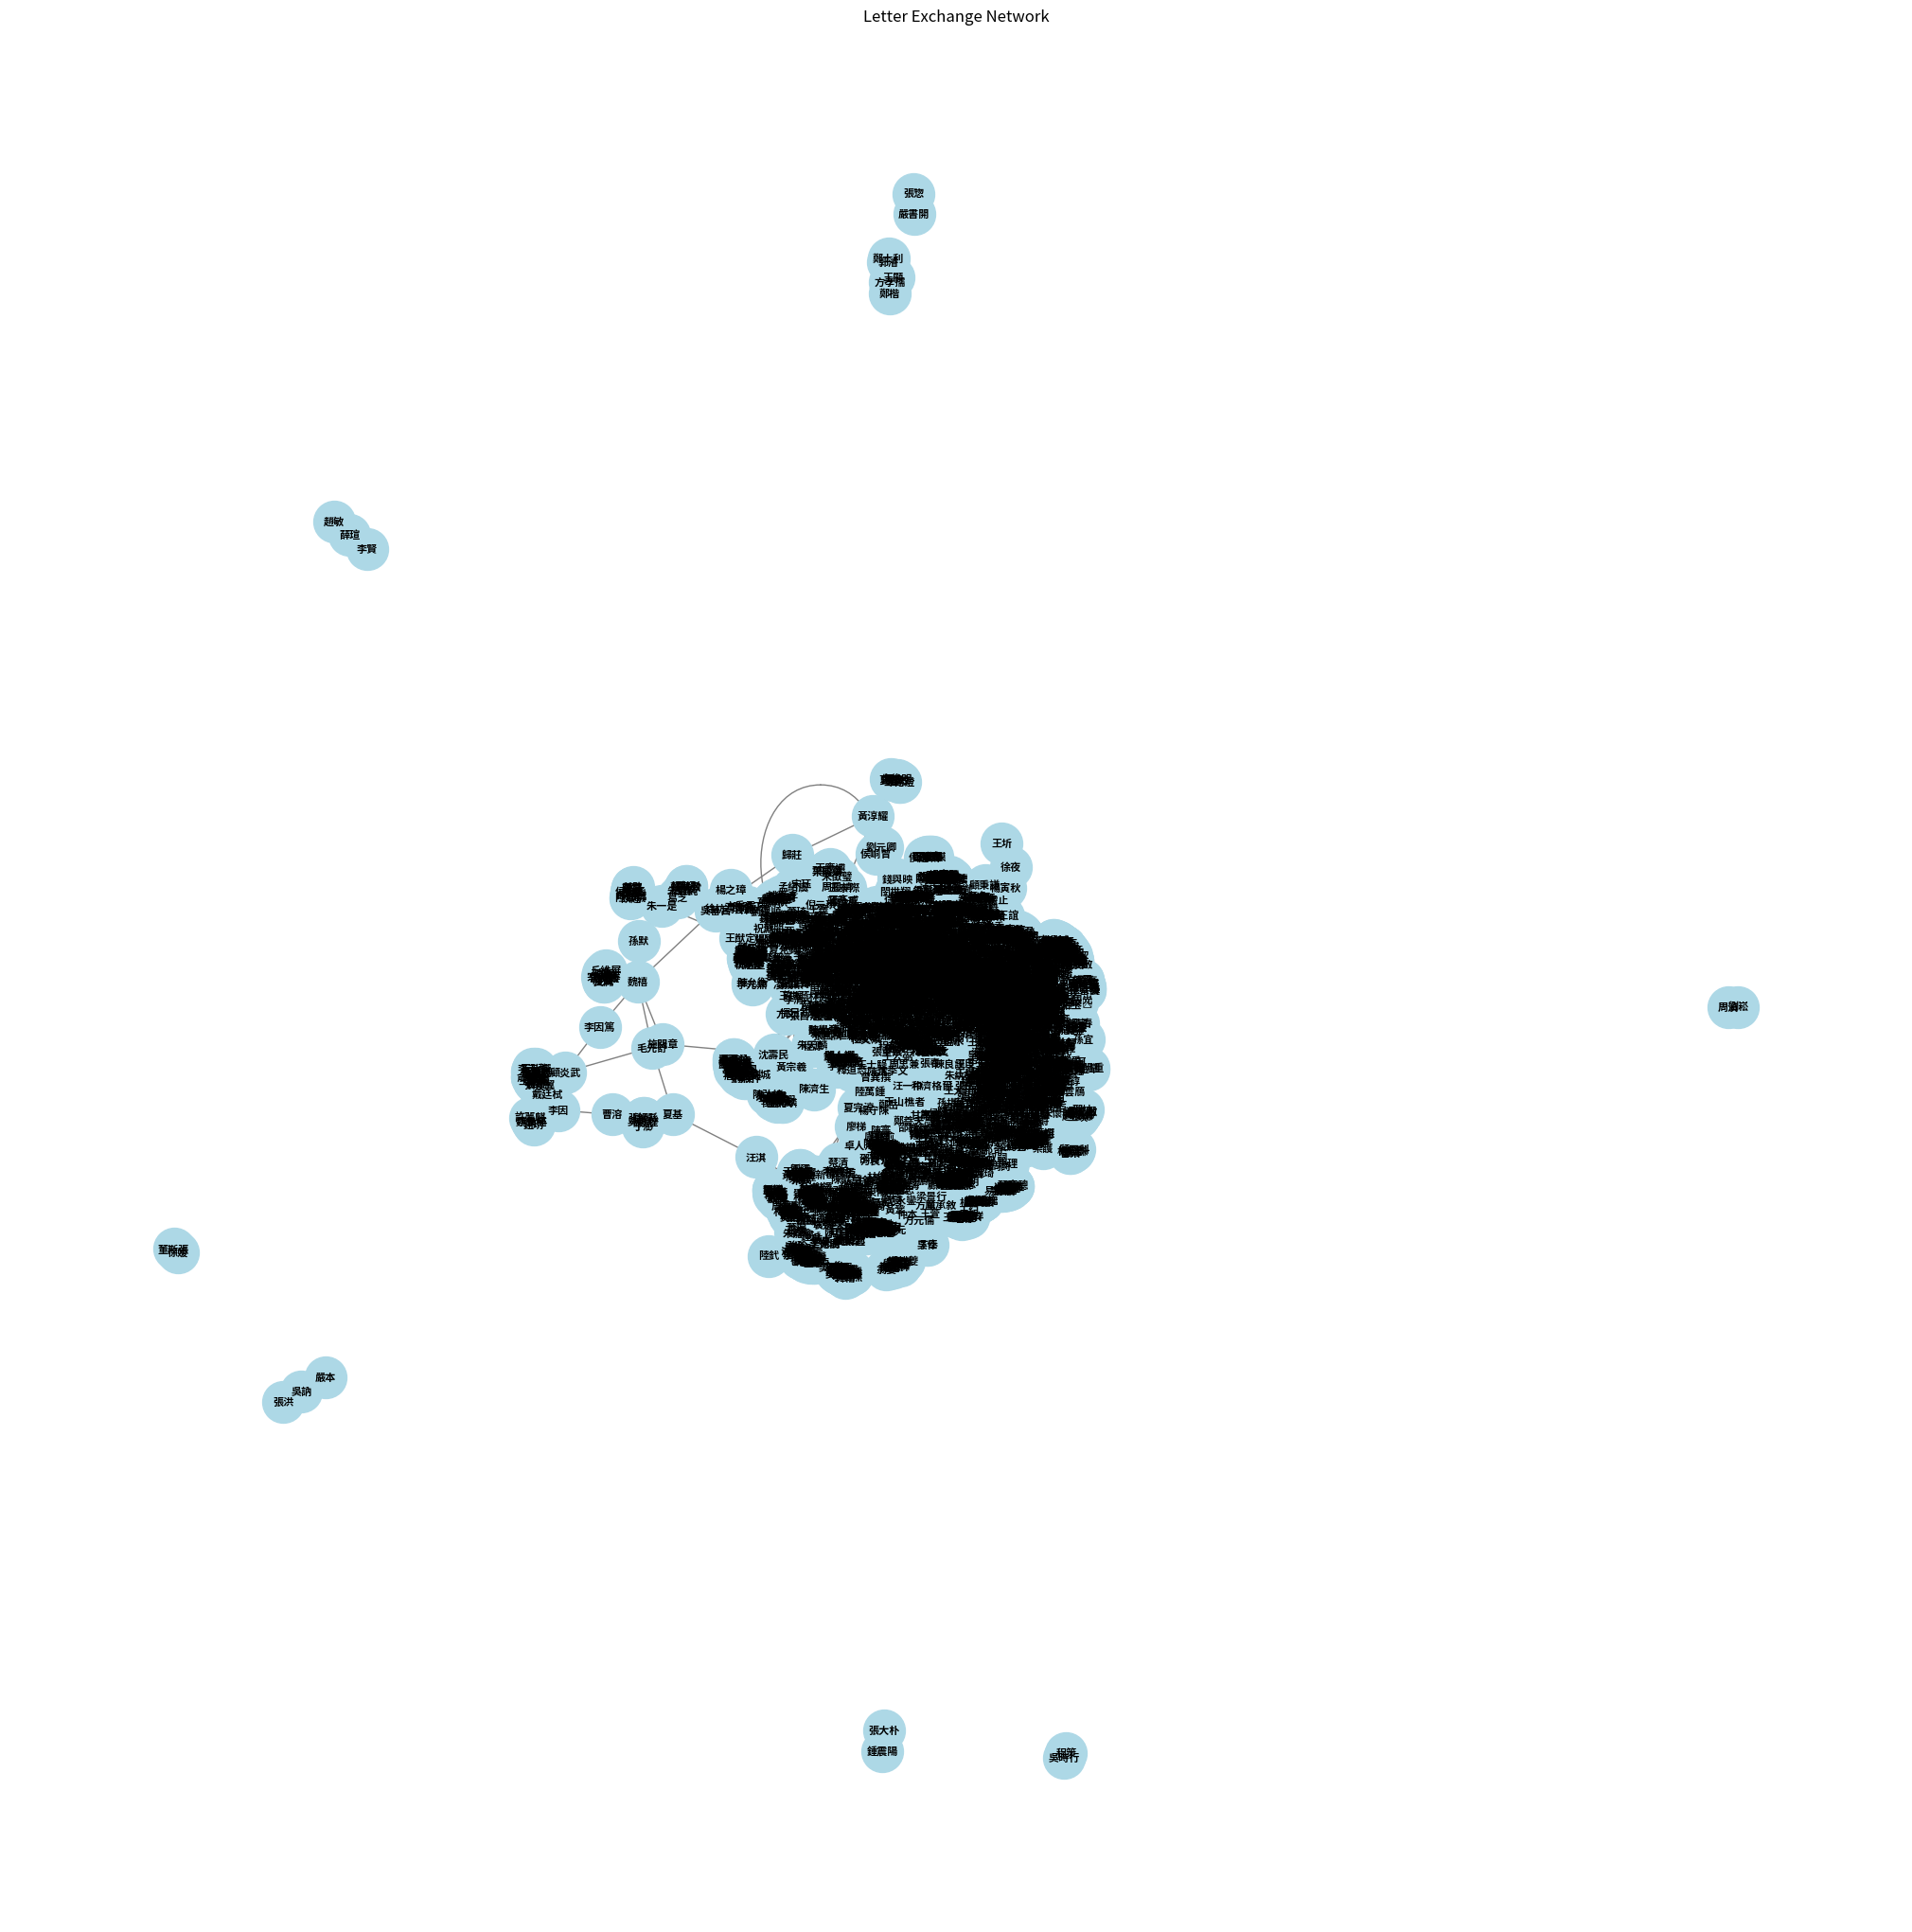

In [48]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an undirected graph
G = nx.Graph()
G.add_edges_from(result.values)

# Use spring layout to position nodes
#pos = nx.spring_layout(G, k=0.3, iterations=50)  # Adjust 'k' and 'iterations' for better spacing

# Visualize the graph
plt.figure(figsize=(20, 20))  # Increase the figure size for better readability
nx.draw(G, with_labels=True, node_color='lightblue', node_size=1000, font_size=8, font_weight='bold', edge_color='gray')
plt.title('Letter Exchange Network')
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an undirected graph
G = nx.Graph()
G.add_edges_from(result.values)

# Use spring layout to position nodes
pos = nx.spring_layout(G, k=0.3, iterations=50)  # Adjust 'k' and 'iterations' for better spacing

In [31]:
# Count the number of letters written by each person
writer_counts = data['writer'].value_counts()

# Keep only writers who wrote 10 or more letters
valid_writers = writer_counts[writer_counts >= 100].index
filtered_data = data[data['writer'].isin(valid_writers)]
print(len(filtered_data))

# Select only the writer and receiver columns
edges = filtered_data[['writer', 'receiver']]

# Create an undirected graph
G = nx.Graph()
G.add_edges_from(edges.values)

# Use spring layout to position nodes
#pos = nx.spring_layout(G, k=0.3, iterations=50)
#pos = nx.kamada_kawai_layout(G)
pos = nx.forceatlas2_layout(G)

8399


  0%|          | 0/1711 [00:00<?, ?it/s]

<ipython-input-32-ed63819d9c8a>:20: UserWarning: Glyph 166399 (\N{CJK UNIFIED IDEOGRAPH-289FF}) missing from current font.
  plt.savefig('letter_exchange_network.png', dpi=600, bbox_inches='tight')
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 166399 (\N{CJK UNIFIED IDEOGRAPH-289FF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


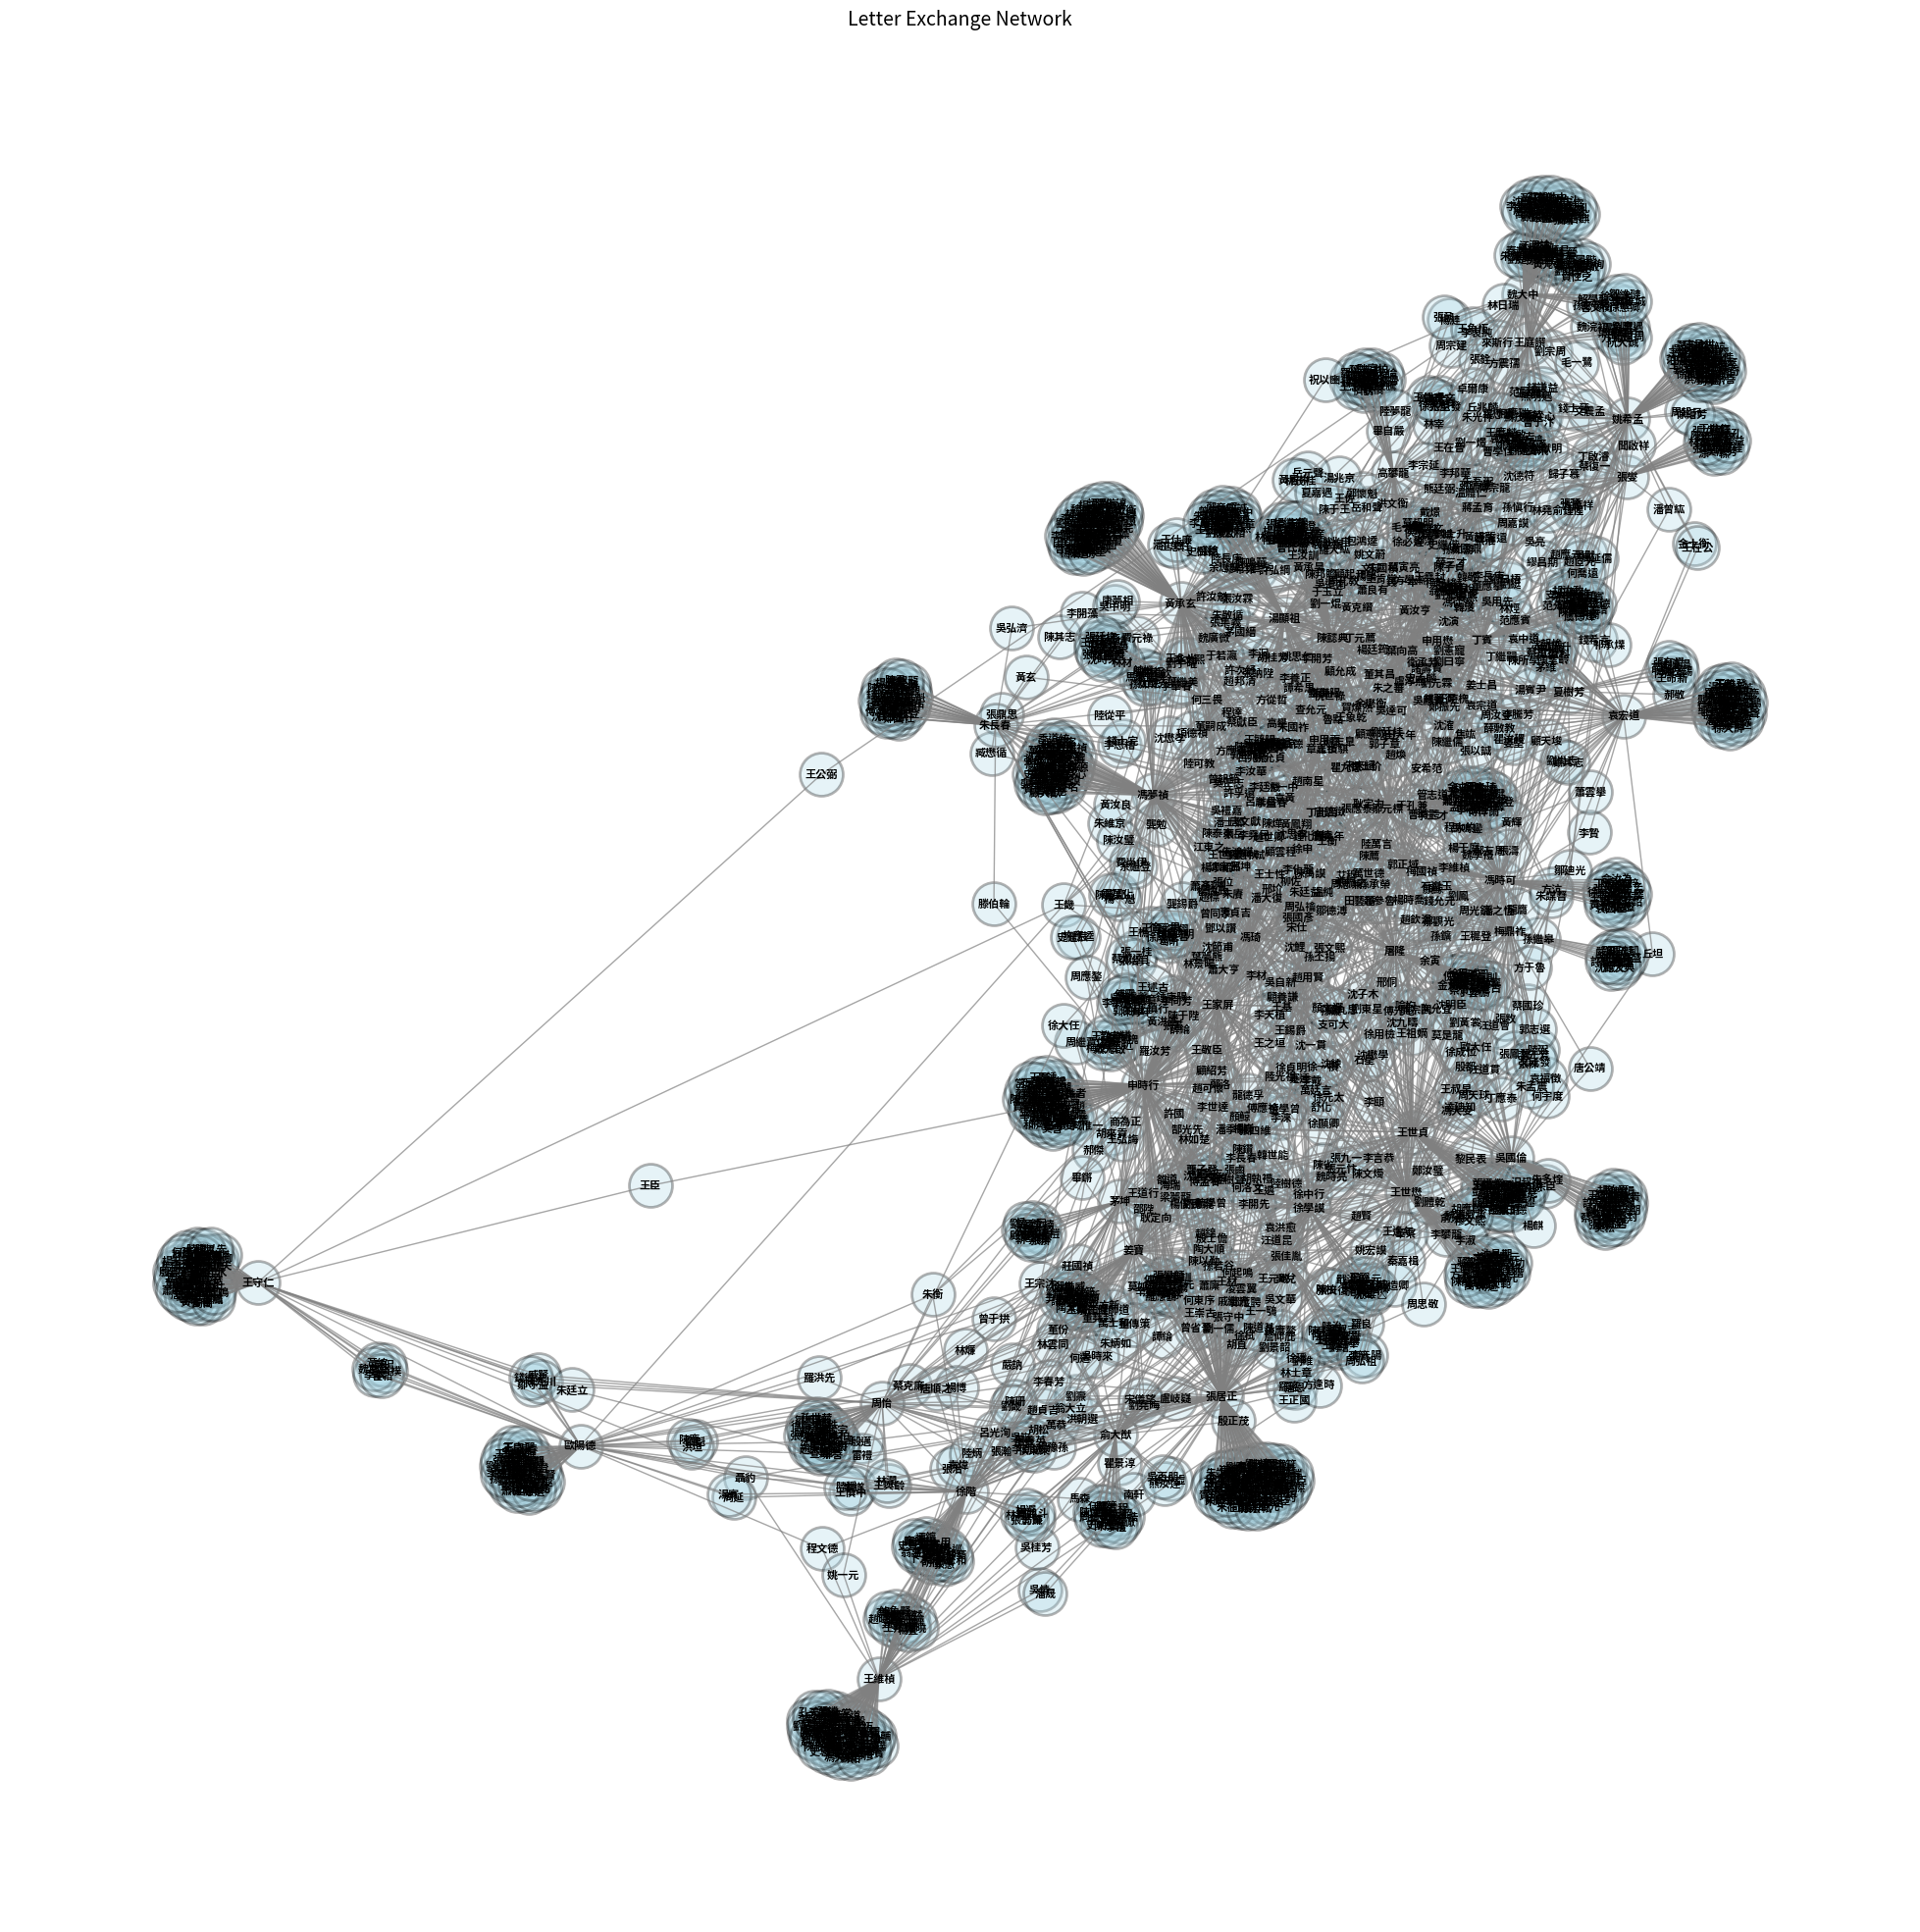

In [32]:
from tqdm.auto import tqdm

# Visualize the graph
plt.figure(figsize=(25, 25))  # Increase the figure size for better readability

# Draw the nodes with borders
for node in tqdm(G.nodes()):
    x, y = pos[node]
    plt.scatter(x, y, s=1000, c='lightblue', edgecolors='black', alpha=0.3, linewidths=2)

# Draw the edges (without zorder)
nx.draw_networkx_edges(G, pos, alpha=0.7, edge_color='gray')

# Draw the labels (without zorder)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# Set the title and show the plot
plt.title('Letter Exchange Network', fontsize=14)
plt.axis('off')  # Turn off the axis
plt.savefig('letter_exchange_network.png', dpi=600, bbox_inches='tight')
plt.show()

In [34]:
# Find nodes with degree 1
nodes_with_degree_one = [node for node, degree in G.degree() if degree == 1]

# Find the "bridge" node they are connected to
bridge_connections = {}
for node in nodes_with_degree_one:
    neighbors = list(G.neighbors(node))
    if neighbors:  # Ensure there is a neighbor
        bridge_node = neighbors[0]
        if bridge_node not in bridge_connections:
            bridge_connections[bridge_node] = []
        bridge_connections[bridge_node].append(node)

# Print bridge nodes and their connected nodes
for bridge_node, connected_nodes in bridge_connections.items():
    if len(connected_nodes) > 1:  # Only consider if there are multiple nodes connected
        print(f"Bridge Node: {bridge_node}, Connected Nodes: {connected_nodes}")


Bridge Node: 王守仁, Connected Nodes: ['顧璘', '周衝', '陸澄', '羅欽順', '徐守誠', '應良', '汪俊', '王雲鳳', '王道', '蔡宗兗', '戴德孺', '黃宗明', '王應鵬', '李恕', '許相卿', '康海', '湛若水', '方獻夫', '陳傑', '唐龍', '朱守忠', '席書', '倫以訓', '舒國用', '黃省曾', '董沄', '南大吉', '馬明衡', '毛憲', '林大輅', '何廷仁', '汪玉', '殷雲霄', '孟源', '顧應祥', '朱箎', '儲瓘', '何孟春', '王瓊', '彭澤', '楊一清', '潘壯', '翟鑾', '郭慶', '楊驥', '朱厚照', '張綖', '林俊', '蕭鳴鳳', '陳以先', '周鵷', '王華', '楊仕鳴']
Bridge Node: 申時行, Connected Nodes: ['王鴻儀', '張任', '和濟格爾', '陳文燧', '辛應乾', '赫瀛', '王湘', '玉山樵者', '劉世曾', '王□', '李松', '翟繡裳', '侯于趙', '李江', '曹大埜', '吳善', '李汶', '蕭崇業', '蔡時鼎', '王廷瞻', '臧惟一', '黃宗庠', '秦燿', '梁問孟', '賈待問', '鄧林喬', '周世選', '沐晟', '劉繼文', '張檟', '周寀', '李鴻漸', '楊成', '蔡汝賢', '黨馨', '李樂', '崔廷試', '李釆菲', '李尚思', '余之禎', '任養心', '李文利', '詹事講', '屠叔方', '王某', '伍可受', '常居敬', '黃鍾', '石應岳']
Bridge Node: 高攀龍, Connected Nodes: ['王汝魯', '儕鶴', '錢大昕', '耿橘', '區大倫', '段然', '耿庭柏', '王志道', '葉茂才', '吳海鏊', '李應祥', '楊應文', '翟鳳翀', '羅尚忠', '陳大綬', '黃一騰', '華允誠']
Bridge Node: 鄒元標, Connected Nodes: ['寧心祖', '濮中玉', '尤光被', '金立敬', '楊道會', '蕭良譽\u3000', '王士琦', '徐即登', '叔簡', 

In [33]:
ev_centrality = nx.eigenvector_centrality(G)
bn_centrality = nx.betweenness_centrality(G)
sorted(((v, c) for v, c in bn_centrality.items()), key = lambda x:-x[1])[:100]

[('張居正', 0.12883070789249648),
 ('王世貞', 0.11968988196189441),
 ('黃承玄', 0.11036730699888592),
 ('申時行', 0.10876248250715953),
 ('馮夢禎', 0.0913517937397562),
 ('王維楨', 0.07500274772497897),
 ('王世懋', 0.06858159938088539),
 ('湯顯祖', 0.06710239302199734),
 ('徐階', 0.06700820315799343),
 ('王守仁', 0.06610973996752988),
 ('姚希孟', 0.06364560637015898),
 ('馮時可', 0.061735408736236216),
 ('鄒元標', 0.060569094199500025),
 ('歐陽德', 0.05668218094659829),
 ('陳懿典', 0.05556927036249835),
 ('魏大中', 0.051897862875145216),
 ('袁宏道', 0.0512160894548636),
 ('姜寶', 0.05081057021730731),
 ('王畿', 0.04957700196422549),
 ('屠隆', 0.04793888176829266),
 ('黃汝亨', 0.04693726405525184),
 ('王家屏', 0.0433561162965252),
 ('吳國倫', 0.04287351213366049),
 ('周怡', 0.04229628024149414),
 ('丁賓', 0.04080588054539897),
 ('馮琦', 0.040233532428653705),
 ('趙南星', 0.03800968127448187),
 ('朱長春', 0.03749490713805074),
 ('王庭譔', 0.035715624641686164),
 ('徐學謨', 0.03426290306154712),
 ('高攀龍', 0.03280475763173959),
 ('葉向高', 0.03058662594678155),
 ('李維楨', 0.03